In [8]:
import pandas as pd # pyright: ignore[reportMissingModuleSource]
import matplotlib.pyplot as plt # pyright: ignore[reportMissingModuleSource]
import numpy as np # pyright: ignore[reportMissingModuleSource]

In [9]:
def convert_col_slf_to_lf(list_of_strings: [str]) -> [[float]]:
    """
    Function CONVERTS input

    FROM
      a column consisting of Strings of lists of floats
    TO
      a column consisting of lists of floats.
    """
    processed_list = []
    for row in list_of_strings:
        strip_paren = row[1:-1]
        row_split = strip_paren.split(",")
        processed_row = [float(val) for val in row_split]
        processed_list.append(processed_row)
    return processed_list

In [12]:
df = pd.read_csv('data.csv')
df.head()

,Timestamp,RAM Used (MB),RAM Total (MB),LFB Count,LFB Size (MB),SWAP Used (MB),SWAP Total (MB),CPU Core Utilizations (%),CPU Core Clocks (MHz),EMC Util (%),...,APE Clock (MHz),Temp CPU (C),Temp SOC2 (C),Temp SOC0 (C),Temp GPU (C),Temp TJ (C),Temp SOC1 (C),VDD_IN Current (mW),VDD_CPU_GPU_CV Current (mW),VDD_SOC Current (mW)
0,05-23-2026 23:22:00,1755,7607,5,4,0,3804,"[0, 0, 0, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",0,...,200,46.437,46.250,47.156,49.750,49.750,48.687,4647,520,1442
1,05-23-2026 23:22:05,1755,7607,5,4,0,3804,"[1, 0, 0, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",1,...,200,46.312,46.125,47.000,49.500,49.500,48.500,4650,522,1445
2,05-23-2026 23:22:10,1756,7607,5,4,0,3804,"[0, 0, 1, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",0,...,200,46.437,46.250,47.156,49.750,49.750,48.687,4642,518,1440
3,05-23-2026 23:22:15,1756,7607,5,4,0,3804,"[2, 0, 0, 0, 1, 0]","[729, 729, 729, 729, 729, 729]",1,...,200,46.500,46.375,47.250,49.875,49.875,48.750,4665,535,1452
4,05-23-2026 23:22:20,1755,7607,5,4,0,3804,"[0, 0, 0, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",0,...,200,46.437,46.250,47.156,49.750,49.750,48.687,4647,520,1442


In [13]:
df.describe()

,RAM Used (MB),RAM Total (MB),LFB Count,LFB Size (MB),SWAP Used (MB),SWAP Total (MB),EMC Util (%),GPU Util (%),GPU Clock (MHz),NVDEC Active,...,APE Clock (MHz),Temp CPU (C),Temp SOC2 (C),Temp SOC0 (C),Temp GPU (C),Temp TJ (C),Temp SOC1 (C),VDD_IN Current (mW),VDD_CPU_GPU_CV Current (mW),VDD_SOC Current (mW)
count,50.000000,50.0,50.000000,50.0,50.0,50.0,50.000000,50.000000,50.000000,50.000000,...,50.0,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2191.340000,7607.0,4.600000,4.0,0.0,3804.0,26.380000,37.700000,428.600000,0.400000,...,200.0,53.572240,52.528680,54.220520,56.982500,56.982500,55.474820,8682.360000,3811.080000,2004.700000
std,528.787431,0.0,0.494872,0.0,0.0,0.0,32.302707,47.276542,152.915343,0.494872,...,0.0,8.514122,7.536027,8.394651,8.729714,8.729714,8.136346,5021.364758,4109.884545,697.147958
min,1755.000000,7607.0,4.000000,4.0,0.0,3804.0,0.000000,0.000000,305.000000,0.000000,...,200.0,46.312000,46.125000,47.000000,49.500000,49.500000,48.500000,4640.000000,515.000000,1438.000000
25%,1755.000000,7607.0,4.000000,4.0,0.0,3804.0,0.000000,0.000000,305.000000,0.000000,...,200.0,46.437000,46.250000,47.156000,49.750000,49.750000,48.687000,4647.000000,520.000000,1442.000000
50%,1756.500000,7607.0,5.000000,4.0,0.0,3804.0,1.000000,0.000000,305.000000,0.000000,...,200.0,47.125000,46.812500,47.875000,50.062500,50.062500,49.125000,4657.500000,527.500000,1448.000000
75%,2845.000000,7607.0,5.000000,4.0,0.0,3804.0,66.000000,96.000000,614.000000,1.000000,...,200.0,63.648000,61.468750,64.093750,67.218750,67.218750,65.093750,14847.500000,8847.500000,2860.000000
max,2850.000000,7607.0,5.000000,4.0,0.0,3804.0,70.000000,99.000000,614.000000,1.000000,...,200.0,66.437000,64.062000,66.937000,70.250000,70.250000,67.812000,15250.000000,9250.000000,2930.000000


In [40]:
# Plotting Data Preparation
num_rows = len(df) + 1
sampling_interval_s = 5
time_s = np.arange(sampling_interval_s, num_rows * sampling_interval_s, step=sampling_interval_s)

ram_used, ram_total = df['RAM Used (MB)'], df['RAM Total (MB)']
ram_util_percent = 100 * ram_used / ram_total
avg_ram_util_percent = np.mean(ram_util_percent)

num_cores = 6
core_util_unprocd = df['CPU Core Utilizations (%)']
core_util_procd = convert_col_slf_to_lf(core_util_unprocd)
core_split = pd.DataFrame(core_util_procd, columns=[f'Core {i}' for i in range(1, num_cores+1)])

gpu_util = df['GPU Util (%)']
avg_gpu_util = np.mean(gpu_util)

temp_cpu = df['Temp CPU (C)']
temp_soc0 = df['Temp SOC0 (C)']
temp_soc1 = df['Temp SOC1 (C)']
temp_soc2 = df['Temp SOC2 (C)']
temp_tj = df['Temp TJ (C)']

temp_gpu = df['Temp GPU (C)']
avg_temp_gpu = np.mean(temp_gpu)

vdd_in = df['VDD_IN Current (mW)']
vdd_gpu_cpu_cv = df['VDD_CPU_GPU_CV Current (mW)']
vdd_soc = df['VDD_SOC Current (mW)']

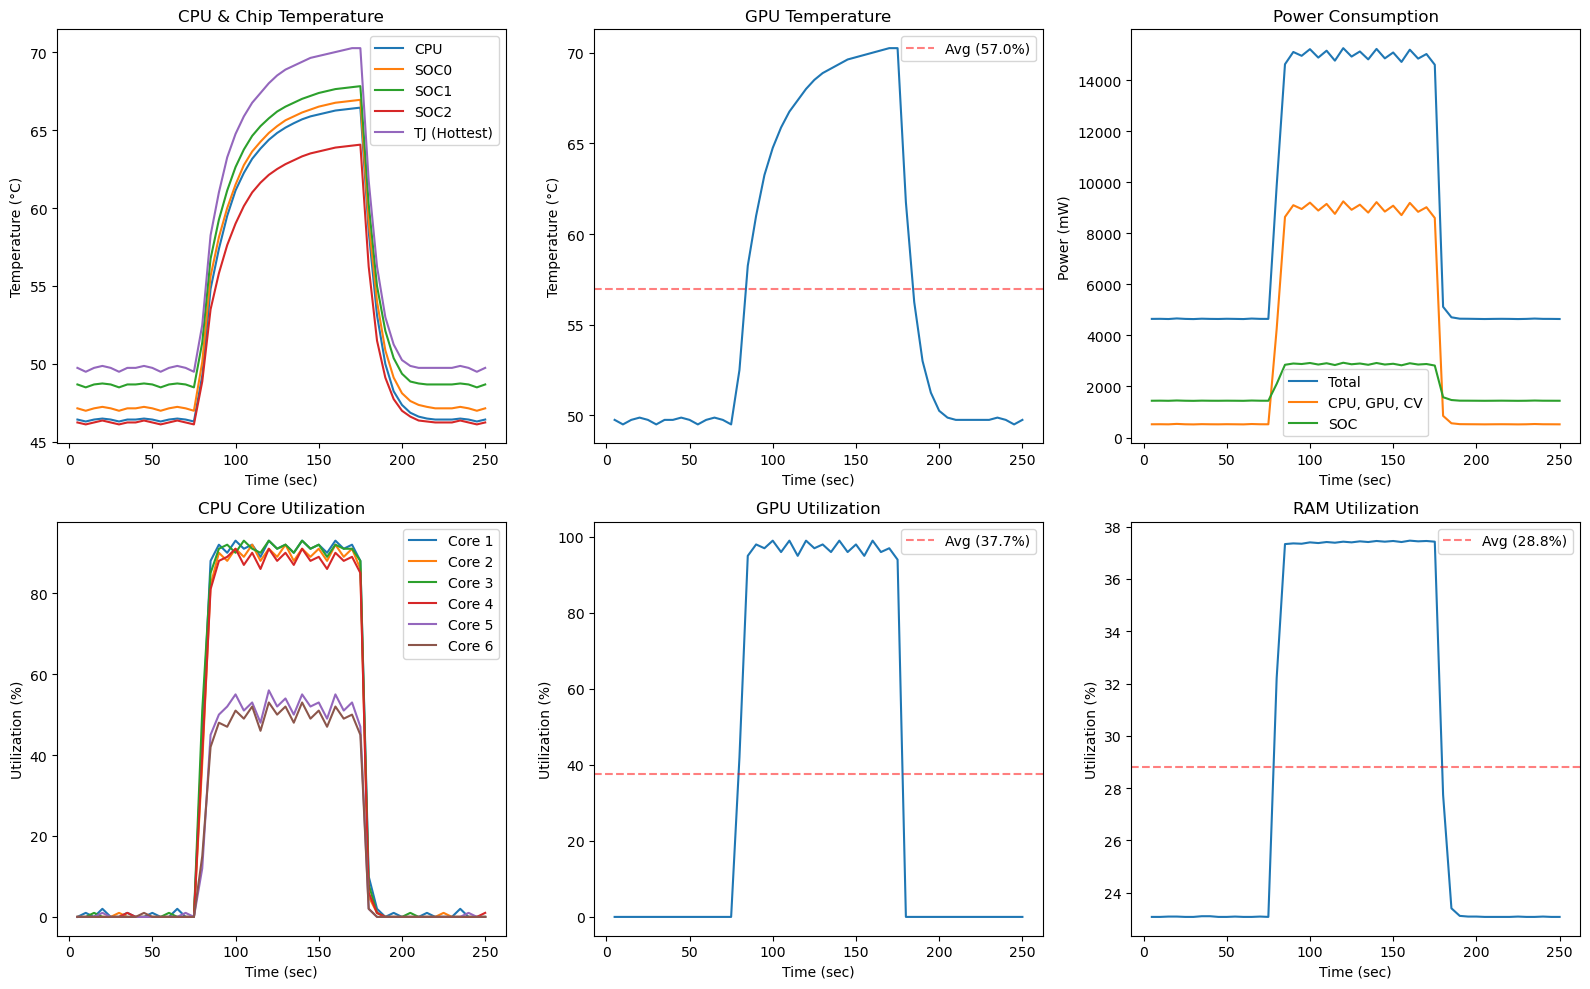

In [45]:
fig, axs = plt.subplots(2, 3, figsize=(16,10))

axs[0,0].plot(time_s, temp_cpu, label="CPU")
axs[0,0].plot(time_s, temp_soc0, label="SOC0")
axs[0,0].plot(time_s, temp_soc1, label="SOC1")
axs[0,0].plot(time_s, temp_soc2, label="SOC2")
axs[0,0].plot(time_s, temp_tj, label="TJ (Hottest)")
axs[0,0].set_title("CPU & Chip Temperature")
axs[0,0].set_ylabel("Temperature (°C)")
axs[0,0].set_xlabel("Time (sec)")
axs[0,0].legend()

axs[0,1].plot(time_s, temp_gpu)
axs[0,1].axhline(y=avg_temp_gpu, color='r', linestyle='--', alpha=0.5, label=f"Avg ({avg_temp_gpu:.1f}%)")
axs[0,1].set_title("GPU Temperature")
axs[0,1].set_ylabel("Temperature (°C)")
axs[0,1].set_xlabel("Time (sec)")
axs[0,1].legend()

axs[0,2].plot(time_s, vdd_in, label='Total')
axs[0,2].plot(time_s, vdd_gpu_cpu_cv, label='CPU, GPU, CV')
axs[0,2].plot(time_s, vdd_soc, label='SOC')
axs[0,2].set_title("Power Consumption")
axs[0,2].set_ylabel("Power (mW)")
axs[0,2].set_xlabel("Time (sec)")
axs[0,2].legend()

for core_name in core_split.columns:
    core_data = core_split[core_name]
    axs[1,0].plot(time_s, core_data, label=core_name)

axs[1,0].set_title("CPU Core Utilization")
axs[1,0].set_ylabel("Utilization (%)")
axs[1,0].set_xlabel("Time (sec)")
axs[1,0].legend()

axs[1,1].plot(time_s, gpu_util)
axs[1,1].axhline(y=avg_gpu_util, color='r', linestyle='--', alpha=0.5, label=f"Avg ({avg_gpu_util:.1f}%)")
axs[1,1].set_title("GPU Utilization")
axs[1,1].set_ylabel("Utilization (%)")
axs[1,1].set_xlabel("Time (sec)")
axs[1,1].legend()

axs[1,2].plot(time_s, ram_util_percent)
axs[1,2].axhline(y=avg_ram_util_percent, color='r', linestyle='--', alpha=0.5, label=f"Avg ({avg_ram_util_percent:.1f}%)")
axs[1,2].set_title("RAM Utilization")
axs[1,2].set_ylabel("Utilization (%)")
axs[1,2].set_xlabel("Time (sec)")
axs[1,2].legend()

plt.tight_layout()
plt.show()

In [23]:
df.head()

,Timestamp,RAM Used (MB),RAM Total (MB),LFB Count,LFB Size (MB),SWAP Used (MB),SWAP Total (MB),CPU Core Utilizations (%),CPU Core Clocks (MHz),EMC Util (%),...,APE Clock (MHz),Temp CPU (C),Temp SOC2 (C),Temp SOC0 (C),Temp GPU (C),Temp TJ (C),Temp SOC1 (C),VDD_IN Current (mW),VDD_CPU_GPU_CV Current (mW),VDD_SOC Current (mW)
0,05-23-2026 23:22:00,1755,7607,5,4,0,3804,"[0, 0, 0, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",0,...,200,46.437,46.250,47.156,49.750,49.750,48.687,4647,520,1442
1,05-23-2026 23:22:05,1755,7607,5,4,0,3804,"[1, 0, 0, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",1,...,200,46.312,46.125,47.000,49.500,49.500,48.500,4650,522,1445
2,05-23-2026 23:22:10,1756,7607,5,4,0,3804,"[0, 0, 1, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",0,...,200,46.437,46.250,47.156,49.750,49.750,48.687,4642,518,1440
3,05-23-2026 23:22:15,1756,7607,5,4,0,3804,"[2, 0, 0, 0, 1, 0]","[729, 729, 729, 729, 729, 729]",1,...,200,46.500,46.375,47.250,49.875,49.875,48.750,4665,535,1452
4,05-23-2026 23:22:20,1755,7607,5,4,0,3804,"[0, 0, 0, 0, 0, 0]","[729, 729, 729, 729, 729, 729]",0,...,200,46.437,46.250,47.156,49.750,49.750,48.687,4647,520,1442


In [49]:
df_1 = df.copy()
df_1['RAM Utilization (%)'] = 100 * df['RAM Used (MB)'] / df['RAM Total (MB)']
c1, c2, c3, c4, c5, c6 = core_split['Core 1'], core_split['Core 2'], core_split['Core 3'], core_split['Core 4'], core_split['Core 5'], core_split['Core 6']
df_1['Avg Core Utilization (%)'] = (c1 + c2 + c3 + c4 + c5 + c6) / num_cores
df_1['VDD_IN (W)'] = df_1['VDD_IN Current (mW)'] / 1000
df_1['VDD_CPU_GPU_CV (W)'] = df_1['VDD_CPU_GPU_CV Current (mW)'] / 1000
df_1['VDD_SOC (W)'] = df_1['VDD_SOC Current (mW)'] / 1000

cols_to_drop = ['Timestamp', 'RAM Used (MB)', 'RAM Total (MB)', 'LFB Count', 'LFB Size (MB)', 'SWAP Used (MB)', 
                'SWAP Total (MB)', 'CPU Core Utilizations (%)', 'EMC Util (%)', 'NVDEC Active', 'NVJPG Active', 
                'NVJPG1 Active', 'VIC Active', 'OFA Active', 'APE Clock (MHz)', 'VDD_IN Current (mW)', 'VDD_CPU_GPU_CV Current (mW)', 'VDD_SOC Current (mW)']

df_1 = df_1.drop(columns=cols_to_drop)
analysis_df = df_1.describe()
analysis_df = analysis_df.drop(index=['count'])
analysis_df = analysis_df.T
pd.set_option('display.float_format', '{:.2f}'.format)
analysis_df

,mean,std,min,25%,50%,75%,max
GPU Util (%),37.70,47.28,0.00,0.00,0.00,96.00,99.00
GPU Clock (MHz),428.60,152.92,305.00,305.00,305.00,614.00,614.00
Temp CPU (C),53.57,8.51,46.31,46.44,47.12,63.65,66.44
Temp SOC2 (C),52.53,7.54,46.12,46.25,46.81,61.47,64.06
Temp SOC0 (C),54.22,8.39,47.00,47.16,47.88,64.09,66.94
Temp GPU (C),56.98,8.73,49.50,49.75,50.06,67.22,70.25
Temp TJ (C),56.98,8.73,49.50,49.75,50.06,67.22,70.25
Temp SOC1 (C),55.47,8.14,48.50,48.69,49.12,65.09,67.81
RAM Utilization (%),28.81,6.95,23.07,23.07,23.09,37.40,37.47
Avg Core Utilization (%),30.01,37.24,0.00,0.17,0.33,76.46,79.50
